<a href="https://colab.research.google.com/github/TKozah/bone-fracture-computer-vision-project/blob/main/v5_notebookB_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🦴 Bone Fracture AI Pipeline — Notebook B: EfficientNet Preprocessing
### Computer Vision Final Project · Saint Joseph University · Spring 2026
### Project Version: CV_project_v4  |  **4-Class Edition**

---

## Prerequisites

**Run Notebook A first.** This notebook reads `dataset_config.json` from Drive.

---

## Purpose

Prepares the **Stage 1 classification pipeline**:
- Defines X-ray-specific image transforms for EfficientNet-B3
- Builds DataLoaders for the **4-class** task
- Computes class weights for the weighted CrossEntropyLoss
- Saves `class_info_v4.pkl` for Notebook C

---

## The 4 Classification Classes

| Index | Class | Meaning |
|---|---|---|
| 0 | `hand_fractured` | Hand X-ray with fracture |
| 1 | `hand_normal` | Hand X-ray without fracture |
| 2 | `leg_fractured` | Leg X-ray with fracture |
| 3 | `leg_normal` | Leg X-ray without fracture |

*(Index order is alphabetical — assigned by torchvision ImageFolder)*

---

## Key Design Decisions

| Decision | Reason |
|---|---|
| `IMG_SIZE = 300` | EfficientNet-B3 native resolution — preserves fine fracture details |
| No ColorJitter | X-ray density encodes bone structure; altering it destroys diagnostic information |
| `Grayscale(num_output_channels=3)` | Some FracAtlas images are L-mode; ensures consistent 3-channel input |
| Moderate rotation ≤15° | X-rays taken at slightly varying angles in practice |
| No aggressive shear | Fracture line orientation is a diagnostic feature |
| ImageNet normalization | Mandatory since EfficientNet-B3 was pretrained on ImageNet |
| Class weights in loss | Handles ~7x imbalance (leg_normal vs leg_fractured) |
| `torch.amp.autocast('cuda')` | Correct API — `torch.cuda.amp.autocast` is deprecated |

---

## Sections

| Section | Task |
|---|---|
| 1 | Install & imports |
| 2 | Mount Drive & load config |
| 3 | Dataset analysis |
| 4 | Define transforms |
| 5 | Build DataLoaders |
| 6 | Compute class weights |
| 7 | Visualize augmented samples |
| 8 | Save class_info_v4.pkl |


---
## 📦 Section 1 — Install & Imports

In [1]:
!pip install -q scikit-learn matplotlib seaborn pandas

In [2]:
import os, json, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Imports done  |  Device: {DEVICE}')
if DEVICE.type != 'cuda':
    print('   ⚠️  No GPU detected. Go to Runtime → Change runtime type → GPU (T4)')


✅ Imports done  |  Device: cuda


---
## ⚙️ Section 2 — Mount Drive & Load Config

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted.')


Mounted at /content/drive
✅ Drive mounted.


In [4]:
CONFIG_PATH = Path('/content/drive/MyDrive/CV_project_v4/dataset_config.json')
if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        'dataset_config.json not found. Run Notebook A first.'
    )

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

PROJECT_ROOT  = Path(cfg['project_root'])
CLF_TRAIN_DIR = Path(cfg['clf_train_dir'])
CLF_VAL_DIR   = Path(cfg['clf_val_dir'])
CLF_TEST_DIR  = Path(cfg['clf_test_dir'])
OUTPUT_DIR    = Path(cfg['output_dir'])
NUM_CLASSES   = cfg['num_clf_classes']        # 4
CLF_CLASSES   = cfg['clf_class_names']        # the 4 class names
INFO_PATH     = PROJECT_ROOT / 'class_info_v4.pkl'

# EfficientNet-B3 native resolution
IMG_SIZE      = 300
BATCH_SIZE    = 32
NUM_WORKERS   = 2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print('✅ Config loaded')
print(f'   Classes ({NUM_CLASSES}): {CLF_CLASSES}')
print(f'   Train:  {CLF_TRAIN_DIR}')
print(f'   Val:    {CLF_VAL_DIR}')
print(f'   IMG_SIZE: {IMG_SIZE}  |  BATCH_SIZE: {BATCH_SIZE}')


✅ Config loaded
   Classes (4): ['hand_fractured', 'hand_normal', 'leg_fractured', 'leg_normal']
   Train:  /content/drive/MyDrive/CV_project_v4/classification_dataset/train
   Val:    /content/drive/MyDrive/CV_project_v4/classification_dataset/val
   IMG_SIZE: 300  |  BATCH_SIZE: 32


---
## 📊 Section 3 — Dataset Analysis

         Class  Train  Val  Test  Total
hand_fractured    284   56    39    379
   hand_normal    676  135    91    902
 leg_fractured    159   31    22    212
    leg_normal   1434  286   192   1912

  Classes:       4
  Train total:   2553
  Avg/class:     638
  Imbalance:     9.02x
  (Hip+shoulder excluded — see Notebook A for justification)


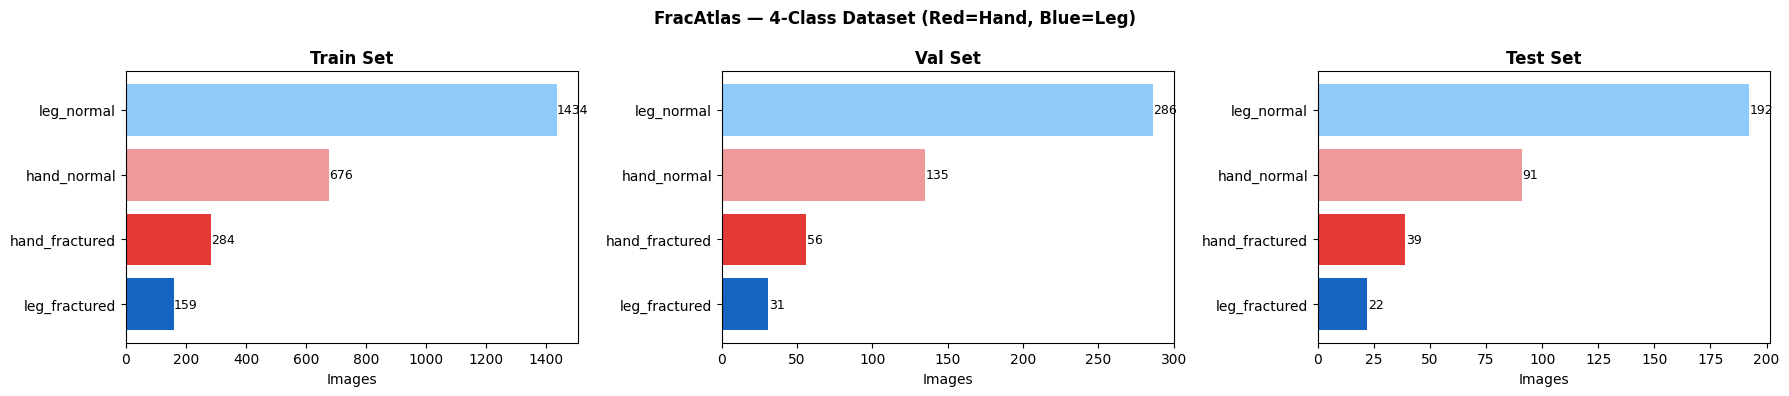

✅ Saved → clf_distribution_B.png


In [5]:
def count_split(split_dir):
    return {
        cls_dir.name: len([f for f in cls_dir.iterdir() if f.is_file()])
        for cls_dir in sorted(Path(split_dir).iterdir()) if cls_dir.is_dir()
    }

tr = count_split(CLF_TRAIN_DIR)
va = count_split(CLF_VAL_DIR)
te = count_split(CLF_TEST_DIR)

df = pd.DataFrame({
    'Class': list(tr.keys()),
    'Train': list(tr.values()),
    'Val':   [va.get(c, 0) for c in tr],
    'Test':  [te.get(c, 0) for c in tr],
})
df['Total'] = df[['Train', 'Val', 'Test']].sum(axis=1)

print(df[['Class', 'Train', 'Val', 'Test', 'Total']].to_string(index=False))
print(f"\n  Classes:       {NUM_CLASSES}")
print(f"  Train total:   {df['Train'].sum()}")
print(f"  Avg/class:     {df['Train'].mean():.0f}")
print(f"  Imbalance:     {df['Train'].max()/df['Train'].min():.2f}x")
print(f"  (Hip+shoulder excluded — see Notebook A for justification)")

# Distribution chart
COLOR_MAP = {
    'hand_fractured': '#E53935', 'hand_normal': '#EF9A9A',
    'leg_fractured':  '#1565C0', 'leg_normal':  '#90CAF9',
}
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, split in zip(axes, ['Train', 'Val', 'Test']):
    sdf    = df.sort_values(split)
    colors = [COLOR_MAP.get(c, '#999') for c in sdf['Class']]
    bars   = ax.barh(sdf['Class'], sdf[split], color=colors)
    ax.set_title(f'{split} Set', fontsize=12, fontweight='bold')
    ax.set_xlabel('Images')
    for bar, v in zip(bars, sdf[split]):
        ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2, str(v), va='center', fontsize=9)
plt.suptitle('FracAtlas — 4-Class Dataset (Red=Hand, Blue=Leg)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clf_distribution_B.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → clf_distribution_B.png')


---
## 🔧 Section 4 — Define Transforms

### X-ray-specific design choices

- **No ColorJitter** — X-ray Hounsfield density encodes bone structure; color shifts destroy this
- **`Grayscale(3)`** — converts L-mode images to 3-channel without altering pixel values
- **Rotation ≤15°** — reflects real clinical variation in X-ray positioning
- **No aggressive shear** — fracture line angle is a diagnostic feature; large shear corrupts it
- **RandomCrop after resize** — mild spatial jitter without distorting anatomical structure


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.Grayscale(num_output_channels=3),   # handles L-mode images
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

baseline_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('✅ Transforms defined')
print('   train:    Resize(332)→RandomCrop(300), H/V flip, Rot15, Affine, Grayscale→3ch, Normalize')
print('   eval:     Resize(300), Grayscale→3ch, Normalize')
print('   ✅ No ColorJitter (X-ray density must be preserved)')
print('   ✅ Grayscale(3) for L-mode image safety')


✅ Transforms defined
   train:    Resize(332)→RandomCrop(300), H/V flip, Rot15, Affine, Grayscale→3ch, Normalize
   eval:     Resize(300), Grayscale→3ch, Normalize
   ✅ No ColorJitter (X-ray density must be preserved)
   ✅ Grayscale(3) for L-mode image safety


---
## 📂 Section 5 — Build DataLoaders

Imbalance ratio (~7x) is above 3x threshold, so WeightedRandomSampler is ON.
**Note from prior failures:** WeightedRandomSampler can overcorrect on severe imbalance.
With 7x (not 204x), it should work correctly here. We also use class weights in loss (Section 6).


In [7]:
from torch.utils.data import WeightedRandomSampler

train_dataset = datasets.ImageFolder(root=str(CLF_TRAIN_DIR), transform=train_transform)
val_dataset   = datasets.ImageFolder(root=str(CLF_VAL_DIR),   transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=str(CLF_TEST_DIR),  transform=eval_transform)

CLASS_TO_IDX    = train_dataset.class_to_idx
IDX_TO_CLASS    = {v: k for k, v in CLASS_TO_IDX.items()}
ORDERED_CLASSES = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]

label_counts = Counter(lbl for _, lbl in train_dataset.samples)
imbalance    = label_counts[max(label_counts, key=label_counts.get)] /                label_counts[min(label_counts, key=label_counts.get)]

USE_SAMPLER = imbalance > 3.0
print(f'Imbalance ratio: {imbalance:.2f}x  →  Sampler: {"ON" if USE_SAMPLER else "OFF"}')

if USE_SAMPLER:
    weights      = [1.0 / label_counts[lbl] for _, lbl in train_dataset.samples]
    sampler      = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f'\n✅ DataLoaders ready')
print(f'   Train: {len(train_dataset)} images  |  {len(train_loader)} batches')
print(f'   Val:   {len(val_dataset)} images  |  {len(val_loader)} batches')
print(f'   Test:  {len(test_dataset)} images  |  {len(test_loader)} batches')
print(f'\nClass mapping (alphabetical order from ImageFolder):')
for i, cls in enumerate(ORDERED_CLASSES):
    print(f'   {i}: {cls:<22}  train={label_counts[i]}')


Imbalance ratio: 9.02x  →  Sampler: ON

✅ DataLoaders ready
   Train: 2553 images  |  80 batches
   Val:   508 images  |  16 batches
   Test:  344 images  |  11 batches

Class mapping (alphabetical order from ImageFolder):
   0: hand_fractured          train=284
   1: hand_normal             train=676
   2: leg_fractured           train=159
   3: leg_normal              train=1434


---
## ⚖️ Section 6 — Compute Class Weights for Loss

Formula: `weight_i = total_train / (num_classes × count_i)`

Higher weight → model penalized more for misclassifying that class → forces learning of minority classes.

In [8]:
total_train   = sum(label_counts.values())
class_weights = [total_train / (NUM_CLASSES * label_counts[i]) for i in range(NUM_CLASSES)]

print('Class weights for CrossEntropyLoss:')
print(f'{"Class":<22} {"Count":>6} {"Weight":>8}  {"Bar"}')
print('─' * 55)
for cls, cnt, w in zip(ORDERED_CLASSES, [label_counts[i] for i in range(NUM_CLASSES)], class_weights):
    bar = '█' * max(1, int(w * 5))
    print(f'{cls:<22} {cnt:>6} {w:>8.4f}  {bar}')

print(f'\nWeight range: {min(class_weights):.4f} – {max(class_weights):.4f}')
print(f'  Highest weight → {ORDERED_CLASSES[class_weights.index(max(class_weights))]} (minority class)')
print(f'  Lowest weight  → {ORDERED_CLASSES[class_weights.index(min(class_weights))]} (majority class)')


Class weights for CrossEntropyLoss:
Class                   Count   Weight  Bar
───────────────────────────────────────────────────────
hand_fractured            284   2.2474  ███████████
hand_normal               676   0.9442  ████
leg_fractured             159   4.0142  ████████████████████
leg_normal               1434   0.4451  ██

Weight range: 0.4451 – 4.0142
  Highest weight → leg_fractured (minority class)
  Lowest weight  → leg_normal (majority class)


---
## 🖼️ Section 7 — Visualize Augmented Samples

Batch shape: torch.Size([32, 3, 300, 300])  min=-2.12  max=2.64  mean=-1.33
✅ Batch sanity check passed (3-channel, 300×300)


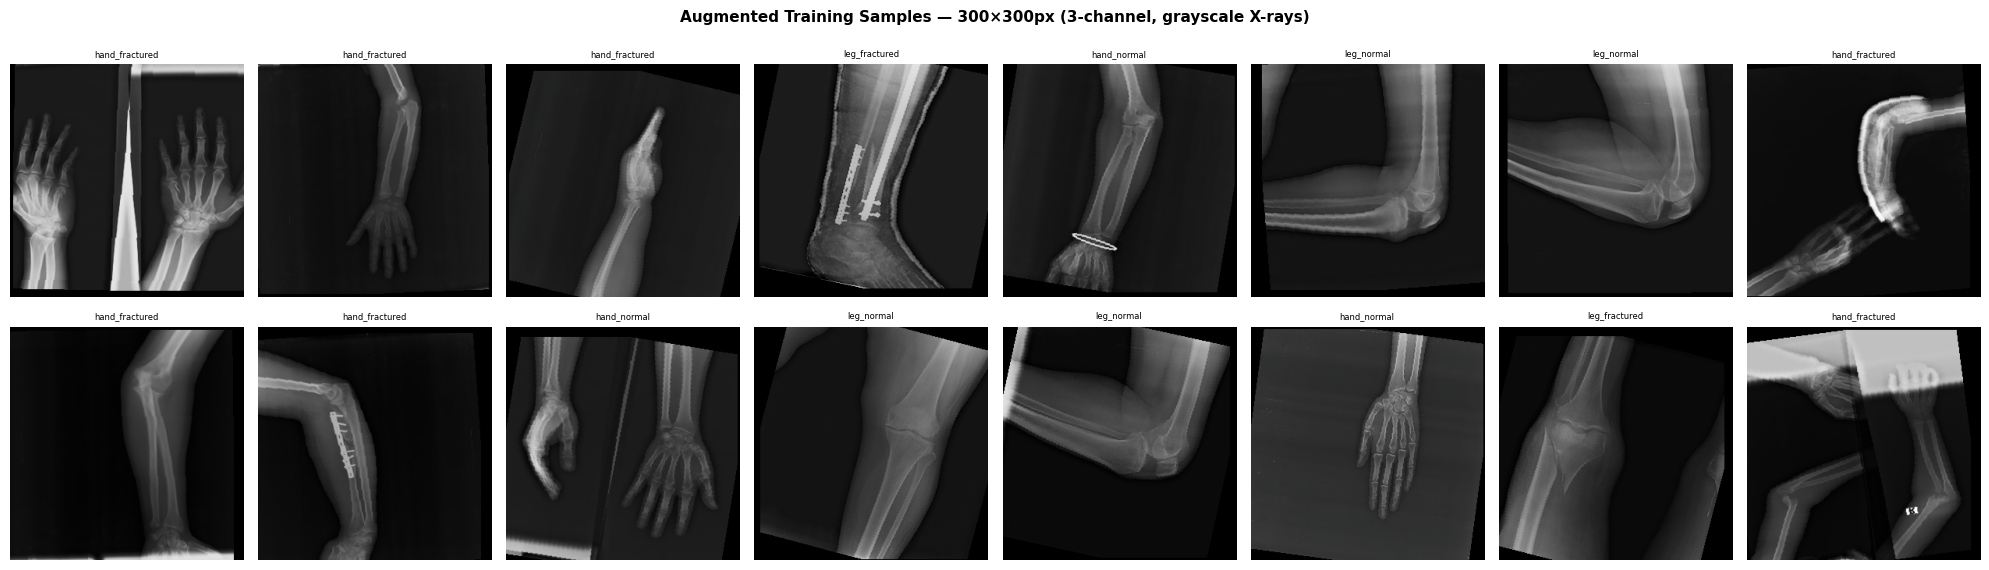

✅ Saved → augmented_samples_4class.png


In [9]:
def denorm(t, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    out = t.clone()
    for i in range(3):
        out[i] = out[i] * std[i] + mean[i]
    return out.clamp(0, 1)

imgs, lbls = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}  '
      f'min={imgs.min():.2f}  max={imgs.max():.2f}  mean={imgs.mean():.2f}')
assert imgs.shape[1] == 3,  f'Expected 3 channels, got {imgs.shape[1]}'
assert imgs.shape[2] == IMG_SIZE, f'Expected {IMG_SIZE}px, got {imgs.shape[2]}'
print('✅ Batch sanity check passed (3-channel, 300×300)')

# Show 2 rows x 8 columns
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flatten()):
    if i < len(imgs):
        ax.imshow(denorm(imgs[i]).permute(1, 2, 0).numpy())
        ax.set_title(IDX_TO_CLASS[lbls[i].item()], fontsize=6)
    ax.axis('off')
plt.suptitle(f'Augmented Training Samples — {IMG_SIZE}×{IMG_SIZE}px (3-channel, grayscale X-rays)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmented_samples_4class.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → augmented_samples_4class.png')


---
## 💾 Section 8 — Save class_info_v4.pkl

In [10]:
dataset_info = {
    # Paths
    'CLF_TRAIN_DIR':      str(CLF_TRAIN_DIR),
    'CLF_VAL_DIR':        str(CLF_VAL_DIR),
    'CLF_TEST_DIR':       str(CLF_TEST_DIR),
    'OUTPUT_DIR':         str(OUTPUT_DIR),
    'PROJECT_ROOT':       str(PROJECT_ROOT),

    # Class setup — 4 classes
    'NUM_CLASSES':        NUM_CLASSES,          # 4
    'ORDERED_CLASSES':    ORDERED_CLASSES,
    'CLASS_TO_IDX':       CLASS_TO_IDX,
    'IDX_TO_CLASS':       IDX_TO_CLASS,
    'class_weights':      class_weights,

    # Training hyperparameters (used by Notebook C)
    'IMG_SIZE':           IMG_SIZE,             # 300
    'BATCH_SIZE':         BATCH_SIZE,           # 32
    'NUM_WORKERS':        NUM_WORKERS,
    'SEED':               SEED,
    'IMAGENET_MEAN':      IMAGENET_MEAN,
    'IMAGENET_STD':       IMAGENET_STD,

    # Transforms
    'train_transform':    train_transform,
    'eval_transform':     eval_transform,
    'baseline_transform': baseline_transform,

    # Sampler info
    'USE_SAMPLER':        USE_SAMPLER,
    'imbalance_ratio':    float(imbalance),
    'label_counts':       dict(label_counts),
}

with open(INFO_PATH, 'wb') as f:
    pickle.dump(dataset_info, f)

print(f'✅ Saved: {INFO_PATH}')
print()
print('=' * 58)
print('  PREPROCESSING COMPLETE — CV_project_v4 (4-CLASS)')
print('=' * 58)
print(f'  Classes:     {NUM_CLASSES}  →  {ORDERED_CLASSES}')
print(f'  Train/Val/Test: {len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}')
print(f'  Image size:  {IMG_SIZE}×{IMG_SIZE}px')
print(f'  Imbalance:   {imbalance:.2f}x')
print(f'  Sampler:     {"ON" if USE_SAMPLER else "OFF"}')
print(f'  class_weights saved to pickle for Notebook C loss function')
print('=' * 58)
print()
print('  ⚠️  CRITICAL REMINDER FOR NOTEBOOK C:')
print('  LR_HEAD must be 3e-3 in Phase 1 (hardcode — do not load from pkl)')
print('  Use torch.amp.autocast("cuda") — NOT torch.cuda.amp.autocast')
print('  class_weights go into nn.CrossEntropyLoss(weight=...) NOT sampler')
print('=' * 58)
print('  NEXT: Run Notebook C (EfficientNet-B3 Training)')


✅ Saved: /content/drive/MyDrive/CV_project_v4/class_info_v4.pkl

  PREPROCESSING COMPLETE — CV_project_v4 (4-CLASS)
  Classes:     4  →  ['hand_fractured', 'hand_normal', 'leg_fractured', 'leg_normal']
  Train/Val/Test: 2553 / 508 / 344
  Image size:  300×300px
  Imbalance:   9.02x
  Sampler:     ON
  class_weights saved to pickle for Notebook C loss function

  ⚠️  CRITICAL REMINDER FOR NOTEBOOK C:
  LR_HEAD must be 3e-3 in Phase 1 (hardcode — do not load from pkl)
  Use torch.amp.autocast("cuda") — NOT torch.cuda.amp.autocast
  class_weights go into nn.CrossEntropyLoss(weight=...) NOT sampler
  NEXT: Run Notebook C (EfficientNet-B3 Training)
